# Идентификация пород собак
Этот ноутбук содержит решение для соревнования Dog Breed Identification.

In [4]:
import os
import json
import shutil
import random
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import kagglehub
import kagglehub.cache
import kagglehub.handle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import train_test_split
import timm
from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm
import matplotlib
from timm.data.mixup import Mixup
from timm.loss import SoftTargetCrossEntropy
import optuna

SEED = 42
EPOCHS = 10
BATCH_SIZE = 32
NUM_WORKERS = 2
LEARNING_RATE_BACKBONE = 1e-5
LEARNING_RATE_CLASSIFIER = 1e-4
WEIGHT_DECAY = 1e-2
PCT_START = 0.2
LABEL_SMOOTHING = 0.1
MIXUP_ALPHA = 0.8
CUTMIX_ALPHA = 1.0
MIXUP_PROB = 0.5
MIXUP_SWITCH_PROB = 0.5
TEST_SIZE = 0.2
IMAGE_SIZE = 384
NUM_CLASSES = 120
MODEL_NAME = "vit_base_patch16_384"
MODEL_TAG = MODEL_NAME.replace("/", "_").replace(".", "_")
DATASET_NAME = "dog-breed-identification"
INTERACTIVE = True
USE_TTA = True
USE_MIXUP = True
USE_ENSEMBLE = True
ENSEMBLE_MODELS = [
    {"name": "tf_efficientnetv2_s.in21k", "weights": "best_tf_efficientnetv2_s_in21k.pth", "optuna_cache": "optuna_effnet.json"},
    {"name": "vit_base_patch16_384","weights": "best_vit_base_patch16_384.pth", "optuna_cache": "optuna_vit.json"},
    {"name": "resnet50", "weights": "best_resnet50.pth", "optuna_cache": "optuna_resnet.json"}
]
ENSEMBLE_WEIGHTS_CACHE = "ensemble_weights.npy"
USE_OPTUNA = True
OPTUNA_TRIALS = 10
OPTUNA_EPOCHS = 2
OPTUNA_SAMPLE = 0.3
OPTUNA_TIMEOUT = None
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
if not INTERACTIVE:
    matplotlib.use("Agg")

## 1. Загрузка и настройка датасета

In [5]:
handle = kagglehub.handle.parse_competition_handle(DATASET_NAME)
cache_path = Path(kagglehub.cache.get_cached_path(handle))
marker_path = Path(kagglehub.cache._get_competitions_completion_marker_filepath(handle))

if cache_path.exists() and marker_path.exists():
    path = cache_path
else:
    from kagglehub.auth import get_username
    username = get_username()
    if username is None:
        print("Вы не авторизованы в Kaggle. Запуск процесса авторизации...")
        kagglehub.login()
        username = get_username()
        if username is None:
            raise RuntimeError("Пожалуйста, введите ваш API-токен Kaggle в интерактивном окне выше и запустите эту ячейку снова.")
    print(f"Вы авторизованы как пользователь: {username}")
    path = kagglehub.competition_download(DATASET_NAME)

DATA_DIR = Path(path)
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
LABELS_CSV = DATA_DIR / "labels.csv"
SAMPLE_SUBMISSION_CSV = DATA_DIR / "sample_submission.csv"

Вы авторизованы как пользователь: feytox


100%|██████████| 691M/691M [00:05<00:00, 130MB/s]

Extracting files...


## 2. Разведочный анализ данных (EDA)
Анализ распределения классов и проверка размеров изображений.

Размер датасета: (10222, 2)
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever
Минимум изображений на породу: 66
Максимум изображений на породу: 126


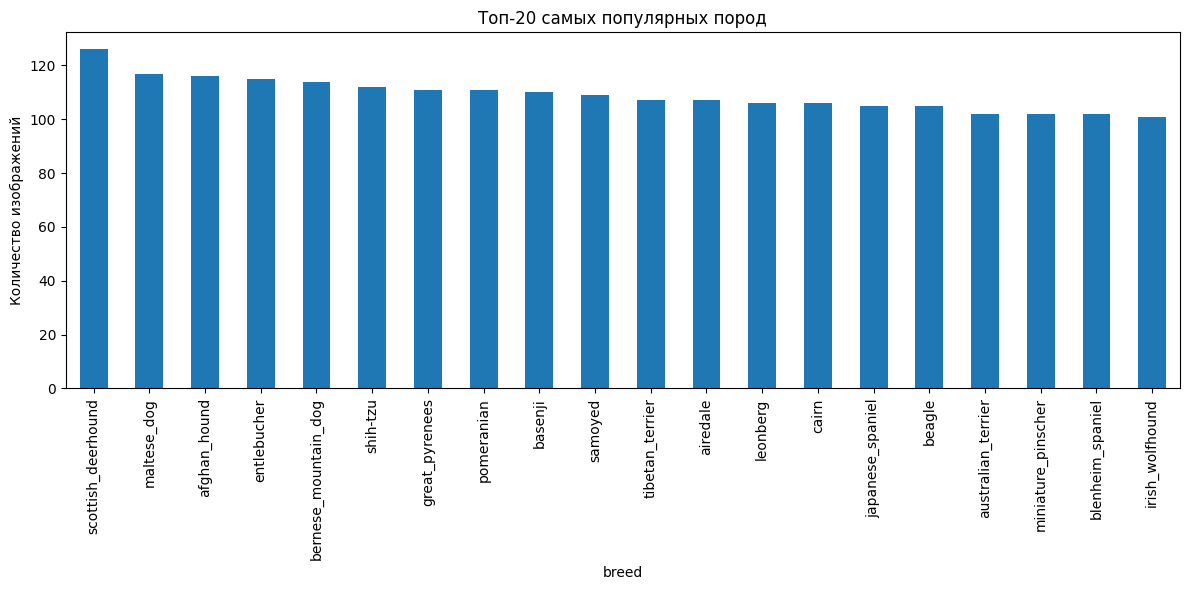

Пример изображения: 000bec180eb18c7604dcecc8fe0dba07.jpg, размер: (500, 375), каналы: RGB


In [6]:
df = pd.read_csv(LABELS_CSV)
print(f"Размер датасета: {df.shape}")
print(df.head())

counts = df["breed"].value_counts()
print(f"Минимум изображений на породу: {counts.min()}")
print(f"Максимум изображений на породу: {counts.max()}")

plt.figure(figsize=(12, 6))
counts.head(20).plot(kind="bar")
plt.title("Топ-20 самых популярных пород")
plt.ylabel("Количество изображений")
plt.tight_layout()
plt.show()

img_id = df.iloc[0]["id"]
img_path = TRAIN_DIR / f"{img_id}.jpg"
img = Image.open(img_path)
print(f"Пример изображения: {img_id}.jpg, размер: {img.size}, каналы: {img.mode}")

## 3. Разделение выборки
Разделение данных на обучающую и валидационную выборки с использованием стратификации для сохранения соотношения классов.

In [7]:
breeds = sorted(df["breed"].unique())
breed_to_idx = {b: i for i, b in enumerate(breeds)}
idx_to_breed = {i: b for i, b in enumerate(breeds)}
df["label"] = df["breed"].map(breed_to_idx)

train_df, val_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df["label"],
    random_state=SEED
)

print(f"Размер обучающей выборки: {train_df.shape[0]}")
print(f"Размер валидационной выборки: {val_df.shape[0]}")

Размер обучающей выборки: 8177
Размер валидационной выборки: 2045


## 4. Класс датасета и загрузчики данных
Определение класса `DogDataset` для загрузки изображений и применение аугментаций для обучения.

In [8]:
class DogDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.ids = df["id"].values
        self.labels = df["label"].values if "label" in df.columns else None

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_name = f"{self.ids[idx]}.jpg"
        img_path = self.img_dir / img_name
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.labels is not None:
            return image, self.labels[idx]
        return image, self.ids[idx]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), shear=10),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(p=0.3, value="random")
])

val_transforms = transforms.Compose([
    transforms.Resize((int(IMAGE_SIZE * 256 / 224), int(IMAGE_SIZE * 256 / 224))),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = DogDataset(train_df, TRAIN_DIR, transform=train_transforms)
val_dataset = DogDataset(val_df, TRAIN_DIR, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

## 5. Инициализация предобученной модели ResNet-34
Загрузка ResNet-34 с весами ImageNet и изменение финального полносвязного слоя для классификации 120 пород собак.

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_TAG = MODEL_NAME.replace("/", "_").replace(".", "_")

model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(device)

print(f"Модель загружена и перемещена на: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/347M [00:00<?, ?B/s]

Модель загружена и перемещена на: cuda


## 5.1 Подбор гиперпараметров с Optuna
Опциональная настройка гиперпараметров на подвыборке данных.

In [10]:
def optimize_hyperparams(model_name, train_df, val_df, cache_path, n_trials=OPTUNA_TRIALS, epochs=OPTUNA_EPOCHS):
    if os.path.exists(cache_path):
        with open(cache_path, "r") as f:
            print(f"Загружены параметры для {model_name} из {cache_path}")
            return json.load(f)

    def objective(trial):
        lr_backbone = trial.suggest_float("lr_backbone", 1e-6, 1e-4, log=True)
        lr_classifier = trial.suggest_float("lr_classifier", 1e-5, 1e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True)
        pct_start = trial.suggest_float("pct_start", 0.1, 0.4)
        label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.2)
        mixup_prob = trial.suggest_float("mixup_prob", 0.0, 0.7)

        if OPTUNA_SAMPLE < 1.0:
            train_sample = train_df.sample(frac=OPTUNA_SAMPLE, random_state=SEED)
            val_sample = val_df.sample(frac=OPTUNA_SAMPLE, random_state=SEED)
        else:
            train_sample, val_sample = train_df, val_df

        train_transforms_local = transforms.Compose([
            transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.6, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
            transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), shear=10),
            transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            transforms.RandomErasing(p=0.3, value="random")
        ])
        val_transforms_local = transforms.Compose([
            transforms.Resize((int(IMAGE_SIZE * 256 / 224), int(IMAGE_SIZE * 256 / 224))),
            transforms.CenterCrop(IMAGE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        train_ds = DogDataset(train_sample, TRAIN_DIR, transform=train_transforms_local)
        val_ds = DogDataset(val_sample, TRAIN_DIR, transform=val_transforms_local)
        train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
        val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

        trial_model = timm.create_model(model_name, pretrained=True, num_classes=NUM_CLASSES).to(device)
        backbone_params = [p for n, p in trial_model.named_parameters() if not ("classifier" in n or "head" in n)]
        classifier_params = [p for n, p in trial_model.named_parameters() if "classifier" in n or "head" in n]

        optimizer = optim.AdamW([
            {"params": backbone_params, "lr": lr_backbone},
            {"params": classifier_params, "lr": lr_classifier}
        ], weight_decay=weight_decay)

        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=[lr_backbone * 10, lr_classifier * 10],
            steps_per_epoch=len(train_dl),
            epochs=epochs,
            pct_start=pct_start
        )

        mixup_fn = Mixup(mixup_alpha=MIXUP_ALPHA, cutmix_alpha=CUTMIX_ALPHA, prob=mixup_prob,
                         switch_prob=MIXUP_SWITCH_PROB, label_smoothing=label_smoothing, num_classes=NUM_CLASSES)
        use_mixup_local = mixup_prob > 0.0
        criterion = SoftTargetCrossEntropy() if use_mixup_local else nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        val_criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        scaler = GradScaler("cuda")

        best_val = float("inf")
        for epoch in range(epochs):
            trial_model.train()
            total = 0
            running_loss = 0.0
            for images, labels in train_dl:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                if use_mixup_local and images.size(0) % 2 == 0:
                    images_mixed, labels_mixed = mixup_fn(images, labels)
                    with autocast("cuda"):
                        outputs = trial_model(images_mixed)
                        loss = criterion(outputs, labels_mixed)
                else:
                    with autocast("cuda"):
                        outputs = trial_model(images)
                        loss = val_criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                running_loss += loss.item() * images.size(0)
                total += labels.size(0)

            trial_model.eval()
            val_loss = 0.0
            val_total = 0
            with torch.no_grad():
                for images, labels in val_dl:
                    images = images.to(device, non_blocking=True)
                    labels = labels.to(device, non_blocking=True)
                    with autocast("cuda"):
                        outputs = trial_model(images)
                        loss = val_criterion(outputs, labels)
                    val_loss += loss.item() * images.size(0)
                    val_total += labels.size(0)
            epoch_val_loss = val_loss / val_total
            best_val = min(best_val, epoch_val_loss)
            trial.report(epoch_val_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
        return best_val

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED),
                                pruner=optuna.pruners.MedianPruner(n_warmup_steps=1))
    study.optimize(objective, n_trials=n_trials, timeout=OPTUNA_TIMEOUT)
    best_params = study.best_params
    with open(cache_path, "w") as f:
        json.dump(best_params, f, indent=2)
    print(f"Лучшие параметры для {model_name} сохранены в {cache_path}: {best_params}")
    return best_params

if USE_OPTUNA:
    for spec in ENSEMBLE_MODELS:
        optimize_hyperparams(spec["name"], train_df, val_df, spec["optuna_cache"], n_trials=OPTUNA_TRIALS, epochs=OPTUNA_EPOCHS)

[I 2026-05-26 15:05:02,476] A new study created in memory with name: no-name-4e1828f2-4bb1-4b80-af3e-7a8335a1ed23


model.safetensors:   0%|          | 0.00/193M [00:00<?, ?B/s]

[I 2026-05-26 15:07:50,867] Trial 0 finished with value: 1.9761911153016727 and parameters: {'lr_backbone': 5.611516415334504e-06, 'lr_classifier': 0.0007969454818643932, 'weight_decay': 0.0029106359131330704, 'pct_start': 0.279597545259111, 'label_smoothing': 0.031203728088487304, 'mixup_prob': 0.10919616423534184}. Best is trial 0 with value: 1.9761911153016727.
[I 2026-05-26 15:10:18,460] Trial 1 finished with value: 2.515981226868272 and parameters: {'lr_backbone': 1.306673923805328e-06, 'lr_classifier': 0.0005399484409787432, 'weight_decay': 0.0015930522616241021, 'pct_start': 0.3124217733388137, 'label_smoothing': 0.004116898859160489, 'mixup_prob': 0.678936896513396}. Best is trial 0 with value: 1.9761911153016727.
[I 2026-05-26 15:12:49,166] Trial 2 finished with value: 2.7927347464359547 and parameters: {'lr_backbone': 4.6225890010208326e-05, 'lr_classifier': 2.6587543983272695e-05, 'weight_decay': 0.0002310201887845295, 'pct_start': 0.15502135295603015, 'label_smoothing': 0.0

Лучшие параметры для tf_efficientnetv2_s.in21k сохранены в optuna_effnet.json: {'lr_backbone': 1.569639638866115e-05, 'lr_classifier': 0.0006978281265126031, 'weight_decay': 0.00015030900645056822, 'pct_start': 0.15879485872574356, 'label_smoothing': 0.009045457782107613, 'mixup_prob': 0.227731231534285}


/tmp/ipykernel_2227/3125870765.py:88: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
[I 2026-05-26 15:33:08,707] Trial 0 finished with value: 1.108695834778031 and parameters: {'lr_backbone': 5.611516415334504e-06, 'lr_classifier': 0.0007969454818643932, 'weight_decay': 0.0029106359131330704, 'pct_start': 0.279597545259111, 'label_smoothing': 0.031203728088487304, 'mixup_prob': 0.10919616423534184}. Best is trial 0 with value: 1.108695834778031.
[I 2026-05-26 15:36:06,142] Trial 1 finished with value: 1.1720062627029342 and parameters: {'lr_backbone': 1.306673923805328e-06, 'lr_classifier': 0.0005399484409787432, 'weight_decay': 0

Лучшие параметры для vit_base_patch16_384 сохранены в optuna_vit.json: {'lr_backbone': 1.569639638866115e-05, 'lr_classifier': 0.0006978281265126031, 'weight_decay': 0.00015030900645056822, 'pct_start': 0.15879485872574356, 'label_smoothing': 0.009045457782107613, 'mixup_prob': 0.227731231534285}


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

[I 2026-05-26 16:01:47,021] Trial 0 finished with value: 4.7571031138640665 and parameters: {'lr_backbone': 5.611516415334504e-06, 'lr_classifier': 0.0007969454818643932, 'weight_decay': 0.0029106359131330704, 'pct_start': 0.279597545259111, 'label_smoothing': 0.031203728088487304, 'mixup_prob': 0.10919616423534184}. Best is trial 0 with value: 4.7571031138640665.
[I 2026-05-26 16:04:19,285] Trial 1 finished with value: 4.782276307332787 and parameters: {'lr_backbone': 1.306673923805328e-06, 'lr_classifier': 0.0005399484409787432, 'weight_decay': 0.0015930522616241021, 'pct_start': 0.3124217733388137, 'label_smoothing': 0.004116898859160489, 'mixup_prob': 0.678936896513396}. Best is trial 0 with value: 4.7571031138640665.
[I 2026-05-26 16:06:41,251] Trial 2 finished with value: 2.8372217816716296 and parameters: {'lr_backbone': 4.6225890010208326e-05, 'lr_classifier': 2.6587543983272695e-05, 'weight_decay': 0.0002310201887845295, 'pct_start': 0.15502135295603015, 'label_smoothing': 0.0

Лучшие параметры для resnet50 сохранены в optuna_resnet.json: {'lr_backbone': 4.6225890010208326e-05, 'lr_classifier': 2.6587543983272695e-05, 'weight_decay': 0.0002310201887845295, 'pct_start': 0.15502135295603015, 'label_smoothing': 0.06084844859190755, 'mixup_prob': 0.3673295021425665}


## 6. Функция потерь и оптимизатор

In [11]:
mixup_fn = Mixup(
    mixup_alpha=MIXUP_ALPHA,
    cutmix_alpha=CUTMIX_ALPHA,
    prob=MIXUP_PROB,
    switch_prob=MIXUP_SWITCH_PROB,
    label_smoothing=LABEL_SMOOTHING,
    num_classes=NUM_CLASSES
)

criterion = SoftTargetCrossEntropy() if USE_MIXUP else nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
val_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

backbone_params = []
classifier_params = []
for name, param in model.named_parameters():
    if "classifier" in name or "head" in name:
        classifier_params.append(param)
    else:
        backbone_params.append(param)

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": LEARNING_RATE_BACKBONE},
    {"params": classifier_params, "lr": LEARNING_RATE_CLASSIFIER}
], weight_decay=WEIGHT_DECAY)

scaler = GradScaler("cuda")

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LEARNING_RATE_BACKBONE * 10, LEARNING_RATE_CLASSIFIER * 10],
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=PCT_START
)

## 7. Цикл обучения и валидации

In [12]:
if not USE_ENSEMBLE:
    best_loss = float("inf")
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total = 0
        progress_bar = tqdm(train_loader, desc=f"Эпоха {epoch+1}/{EPOCHS} [Train]")
        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            if USE_MIXUP and images.size(0) % 2 == 0:
                images_mixed, labels_mixed = mixup_fn(images, labels)
                with autocast("cuda"):
                    outputs = model(images_mixed)
                    loss = criterion(outputs, labels_mixed)
            else:
                with autocast("cuda"):
                    outputs = model(images)
                    loss = val_criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            running_correct += (predicted == labels).sum().item()
            total += labels.size(0)
            progress_bar.set_postfix({"Loss": f"{running_loss / total:.4f}", "Acc": f"{running_correct / total:.4f}"})
        epoch_train_loss = running_loss / total
        epoch_train_acc = running_correct / total
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_progress_bar = tqdm(val_loader, desc=f"Эпоха {epoch+1}/{EPOCHS} [Val]")
        with torch.no_grad():
            for images, labels in val_progress_bar:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                with autocast("cuda"):
                    outputs = model(images)
                    if USE_TTA:
                        outputs_flipped = model(torch.flip(images, dims=[3]))
                        probs = (torch.softmax(outputs, dim=1) + torch.softmax(outputs_flipped, dim=1)) / 2
                        outputs = torch.log(probs + 1e-7)
                    loss = val_criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
                val_progress_bar.set_postfix({"Loss": f"{val_loss / val_total:.4f}", "Acc": f"{val_correct / val_total:.4f}"})
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        print(f"Эпоха {epoch+1}/{EPOCHS}")
        print(f"Train LogLoss: {epoch_train_loss:.4f} - Train Accuracy: {epoch_train_acc:.4f}")
        print(f"Val LogLoss: {epoch_val_loss:.4f} - Val Accuracy: {epoch_val_acc:.4f}")
        if epoch_val_loss < best_loss:
            best_loss = epoch_val_loss
            torch.save(model.state_dict(), f"best_{MODEL_TAG}.pth")
            print("Сохранена лучшая модель.")
else:
    print("Режим ансамбля – обучение отдельных моделей будет выполнено позже.")

Режим ансамбля – обучение отдельных моделей будет выполнено позже.


## 7.1 Функции для ансамбля
При включенном ансамбле веса для каждой модели будут автоматически обучены, если файла нет.

In [13]:
def train_single_model(model_spec):
    model_name = model_spec["name"]
    weights_path = model_spec["weights"]
    optuna_cache = model_spec["optuna_cache"]

    with open(optuna_cache, "r") as f:
        hp = json.load(f)
    lr_backbone = hp["lr_backbone"]
    lr_classifier = hp["lr_classifier"]
    weight_decay = hp["weight_decay"]
    pct_start = hp["pct_start"]
    label_smoothing = hp["label_smoothing"]
    mixup_prob = hp["mixup_prob"]
    use_mixup_local = mixup_prob > 0.0

    print(f"Обучение модели: {model_name} с параметрами {hp}")

    model = timm.create_model(model_name, pretrained=True, num_classes=NUM_CLASSES).to(device)

    mixup_fn = Mixup(mixup_alpha=MIXUP_ALPHA, cutmix_alpha=CUTMIX_ALPHA, prob=mixup_prob,
                     switch_prob=MIXUP_SWITCH_PROB, label_smoothing=label_smoothing, num_classes=NUM_CLASSES)
    criterion = SoftTargetCrossEntropy() if use_mixup_local else nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    val_criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    backbone_params = [p for n, p in model.named_parameters() if not ("classifier" in n or "head" in n)]
    classifier_params = [p for n, p in model.named_parameters() if "classifier" in n or "head" in n]

    optimizer = optim.AdamW([
        {"params": backbone_params, "lr": lr_backbone},
        {"params": classifier_params, "lr": lr_classifier}
    ], weight_decay=weight_decay)
    scaler = GradScaler("cuda")
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[lr_backbone * 10, lr_classifier * 10],
        steps_per_epoch=len(train_loader),
        epochs=EPOCHS,
        pct_start=pct_start
    )

    best_loss = float("inf")
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total = 0
        progress_bar = tqdm(train_loader, desc=f"Эпоха {epoch+1}/{EPOCHS} [Train]")
        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            if use_mixup_local and images.size(0) % 2 == 0:
                images_mixed, labels_mixed = mixup_fn(images, labels)
                with autocast("cuda"):
                    outputs = model(images_mixed)
                    loss = criterion(outputs, labels_mixed)
            else:
                with autocast("cuda"):
                    outputs = model(images)
                    loss = val_criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            running_correct += (predicted == labels).sum().item()
            total += labels.size(0)
            progress_bar.set_postfix({"Loss": f"{running_loss / total:.4f}", "Acc": f"{running_correct / total:.4f}"})
        epoch_train_loss = running_loss / total
        epoch_train_acc = running_correct / total
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_progress_bar = tqdm(val_loader, desc=f"Эпоха {epoch+1}/{EPOCHS} [Val]")
        with torch.no_grad():
            for images, labels in val_progress_bar:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                with autocast("cuda"):
                    outputs = model(images)
                    if USE_TTA:
                        outputs_flipped = model(torch.flip(images, dims=[3]))
                        probs = (torch.softmax(outputs, dim=1) + torch.softmax(outputs_flipped, dim=1)) / 2
                        outputs = torch.log(probs + 1e-7)
                    loss = val_criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
                val_progress_bar.set_postfix({"Loss": f"{val_loss / val_total:.4f}", "Acc": f"{val_correct / val_total:.4f}"})
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        print(f"Эпоха {epoch+1}/{EPOCHS}")
        print(f"Train LogLoss: {epoch_train_loss:.4f} - Train Accuracy: {epoch_train_acc:.4f}")
        print(f"Val LogLoss: {epoch_val_loss:.4f} - Val Accuracy: {epoch_val_acc:.4f}")
        if epoch_val_loss < best_loss:
            best_loss = epoch_val_loss
            torch.save(model.state_dict(), weights_path)
            print("Сохранена лучшая модель.")

def ensure_models_trained(model_specs):
    for spec in model_specs:
        if os.path.exists(spec["weights"]):
            print(f"Найдены веса: {spec['weights']}")
            continue
        train_single_model(spec)

def load_model_with_weights(model_name, weights_path, device):
    model = timm.create_model(model_name, pretrained=True, num_classes=NUM_CLASSES)
    state = torch.load(weights_path, map_location=device)
    model.load_state_dict(state)
    model.to(device)
    model.eval()
    return model

def predict_probs(model, images):
    with autocast("cuda"):
        outputs = model(images)
        if USE_TTA:
            outputs_flipped = model(torch.flip(images, dims=[3]))
            probs = (torch.softmax(outputs, dim=1) + torch.softmax(outputs_flipped, dim=1)) / 2
        else:
            probs = torch.softmax(outputs, dim=1)
    return probs

def optimize_ensemble_weights(model_specs, val_loader):
    if os.path.exists(ENSEMBLE_WEIGHTS_CACHE):
        return np.load(ENSEMBLE_WEIGHTS_CACHE)
    ensure_models_trained(model_specs)
    models = [load_model_with_weights(spec["name"], spec["weights"], device) for spec in model_specs]
    all_probs_list = []
    all_labels = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            batch_probs = []
            for model in models:
                probs = predict_probs(model, images)
                batch_probs.append(probs.cpu().numpy())
            all_probs_list.append(np.stack(batch_probs, axis=1))
            all_labels.extend(labels.cpu().numpy())
    all_probs = np.concatenate(all_probs_list, axis=0)
    all_labels = np.array(all_labels)
    from scipy.optimize import minimize
    from sklearn.metrics import log_loss
    def loss(weights_log):
        weights = np.exp(weights_log) / np.sum(np.exp(weights_log))
        weighted_probs = np.tensordot(all_probs, weights, axes=([1], [0]))
        return log_loss(all_labels, weighted_probs, labels=np.arange(NUM_CLASSES))
    init_weights = np.zeros(len(model_specs))
    res = minimize(loss, init_weights, method='L-BFGS-B')
    best_weights = np.exp(res.x) / np.sum(np.exp(res.x))
    np.save(ENSEMBLE_WEIGHTS_CACHE, best_weights)
    print(f"Оптимальные веса ансамбля: {best_weights}")
    return best_weights

def ensemble_predict_with_labels(loader, model_specs):
    ensure_models_trained(model_specs)
    models = [load_model_with_weights(spec["name"], spec["weights"], device) for spec in model_specs]
    weights = optimize_ensemble_weights(model_specs, val_loader)
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            probs_sum = None
            for w, model in zip(weights, models):
                probs = predict_probs(model, images)
                probs_sum = probs * w if probs_sum is None else probs_sum + probs * w
            all_probs.append(probs_sum.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.vstack(all_probs), np.array(all_labels)

def ensemble_predict(loader, model_specs):
    ensure_models_trained(model_specs)
    models = [load_model_with_weights(spec["name"], spec["weights"], device) for spec in model_specs]
    weights = optimize_ensemble_weights(model_specs, val_loader)
    all_probs = []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device, non_blocking=True)
            probs_sum = None
            for w, model in zip(weights, models):
                probs = predict_probs(model, images)
                probs_sum = probs * w if probs_sum is None else probs_sum + probs * w
            all_probs.append(probs_sum.cpu().numpy())
    return np.vstack(all_probs)

## 8. Качественная оценка модели

### 8.1 Получение предсказаний на валидационной выборке

In [14]:
from sklearn.metrics import classification_report, log_loss

if USE_ENSEMBLE:
    all_probs, all_labels = ensemble_predict_with_labels(val_loader, ENSEMBLE_MODELS)
    all_preds = np.argmax(all_probs, axis=1)
else:
    model.load_state_dict(torch.load(f"best_{MODEL_TAG}.pth", map_location=device))
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast("cuda"):
                outputs = model(images)
                if USE_TTA:
                    outputs_flipped = model(torch.flip(images, dims=[3]))
                    probs = (torch.softmax(outputs, dim=1) + torch.softmax(outputs_flipped, dim=1)) / 2
                else:
                    probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(probs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

Обучение модели: tf_efficientnetv2_s.in21k с параметрами {'lr_backbone': 1.569639638866115e-05, 'lr_classifier': 0.0006978281265126031, 'weight_decay': 0.00015030900645056822, 'pct_start': 0.15879485872574356, 'label_smoothing': 0.009045457782107613, 'mixup_prob': 0.227731231534285}


Эпоха 1/10 [Train]:   0%|          | 0/256 [00:00<?, ?it/s]

Эпоха 1/10 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]

Эпоха 1/10
Train LogLoss: 3.7649 - Train Accuracy: 0.2075
Val LogLoss: 1.6541 - Val Accuracy: 0.5756
Сохранена лучшая модель.


Эпоха 2/10 [Train]:   0%|          | 0/256 [00:00<?, ?it/s]

...

Эпоха 10/10 [Train]:   0%|          | 0/256 [00:00<?, ?it/s]

Эпоха 10/10 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]

Эпоха 10/10
Train LogLoss: 1.2479 - Train Accuracy: 0.8153
Val LogLoss: 0.8856 - Val Accuracy: 0.8929
Найдены веса: best_tf_efficientnetv2_s_in21k.pth
Найдены веса: best_vit_base_patch16_384.pth
Найдены веса: best_resnet50.pth


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: T

Оптимальные веса ансамбля: [4.13802580e-05 1.95349335e-01 8.04609285e-01]


### 8.2 Расчет метрик качества (Accuracy и Log Loss)

In [15]:
val_acc = np.mean(all_preds == all_labels)
val_logloss = log_loss(all_labels, all_probs, labels=np.arange(NUM_CLASSES))

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Log Loss: {val_logloss:.4f}")

Validation Accuracy: 0.8973
Validation Log Loss: 0.4405


### 8.3 Топ-10 легких и сложных пород собак по F1-Score

In [16]:
report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=breeds,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
breed_metrics = report_df.iloc[:-3].copy()

top_10_easy = breed_metrics.sort_values(by="f1-score", ascending=False).head(10)
print("Топ-10 пород с наивысшим F1-Score:")
display(top_10_easy[["precision", "recall", "f1-score"]])

top_10_hard = breed_metrics.sort_values(by="f1-score", ascending=True).head(10)
print("Топ-10 пород с наименьшим F1-Score:")
display(top_10_hard[["precision", "recall", "f1-score"]])

Топ-10 пород с наивысшим F1-Score:


,precision,recall,f1-score
afghan_hound,1.0,1.0,1.0
african_hunting_dog,1.0,1.0,1.0
border_terrier,1.0,1.0,1.0
bedlington_terrier,1.0,1.0,1.0
doberman,1.0,1.0,1.0
dhole,1.0,1.0,1.0
chow,1.0,1.0,1.0
brittany_spaniel,1.0,1.0,1.0
german_short-haired_pointer,1.0,1.0,1.0
norwegian_elkhound,1.0,1.0,1.0


Топ-10 пород с наименьшим F1-Score:


,precision,recall,f1-score
eskimo_dog,0.600000,0.230769,0.333333
walker_hound,0.714286,0.357143,0.476190
miniature_poodle,0.636364,0.437500,0.518519
collie,0.714286,0.588235,0.645161
siberian_husky,0.625000,0.789474,0.697674
lhasa,0.636364,0.777778,0.700000
lakeland_terrier,0.736842,0.700000,0.717949
wire-haired_fox_terrier,0.785714,0.687500,0.733333
australian_terrier,0.823529,0.666667,0.736842
cardigan,0.833333,0.666667,0.740741


### 8.4 Наиболее частые ошибки классификации (Confusion Matrix)

In [17]:
confusion_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for t, p in zip(all_labels, all_preds):
    confusion_matrix[t, p] += 1

confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and confusion_matrix[i, j] > 0:
            confused_pairs.append((idx_to_breed[i], idx_to_breed[j], confusion_matrix[i, j]))

confused_pairs = sorted(confused_pairs, key=lambda x: x[2], reverse=True)

confused_pairs_df = pd.DataFrame(confused_pairs[:10], columns=["Истинная порода", "Предсказанная порода", "Количество ошибок"])
print("Топ-10 наиболее часто путаемых пар пород:")
display(confused_pairs_df)

Топ-10 наиболее часто путаемых пар пород:


,Истинная порода,Предсказанная порода,Количество ошибок
0,eskimo_dog,siberian_husky,6
1,collie,border_collie,5
2,miniature_poodle,toy_poodle,5
3,walker_hound,english_foxhound,5
4,cardigan,pembroke,4
5,eskimo_dog,malamute,4
6,wire-haired_fox_terrier,lakeland_terrier,4
7,kelpie,dingo,3
8,malamute,siberian_husky,3
9,walker_hound,basset,3


### 8.5 Визуализация правильных и ошибочных предсказаний

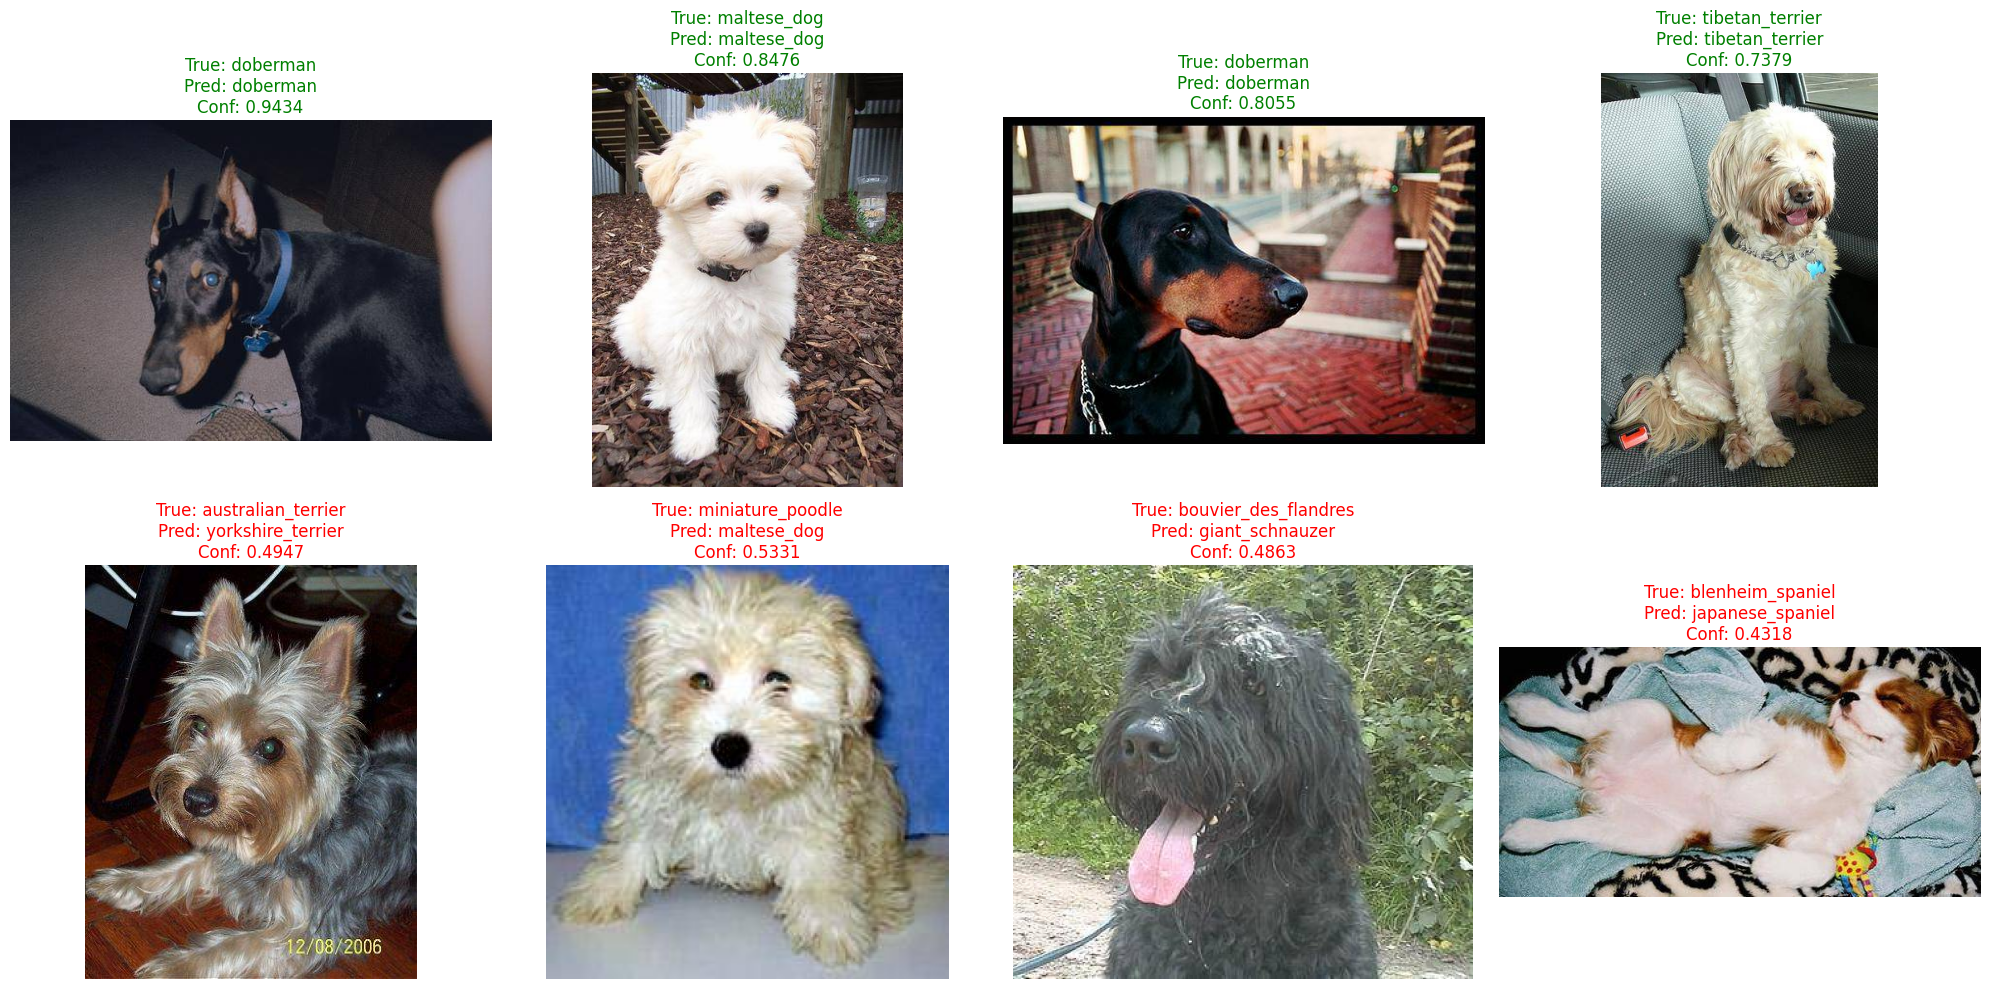

In [18]:
val_df_with_preds = val_df.copy()
val_df_with_preds["predicted_label"] = all_preds
val_df_with_preds["predicted_breed"] = val_df_with_preds["predicted_label"].map(idx_to_breed)
val_df_with_preds["confidence"] = [probs[p] for probs, p in zip(all_probs, all_preds)]
val_df_with_preds["correct"] = val_df_with_preds["label"] == val_df_with_preds["predicted_label"]

correct_samples = val_df_with_preds[val_df_with_preds["correct"]].sample(n=min(4, len(val_df_with_preds[val_df_with_preds["correct"]])), random_state=SEED)
incorrect_samples = val_df_with_preds[~val_df_with_preds["correct"]].sample(n=min(4, len(val_df_with_preds[~val_df_with_preds["correct"]])), random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, (_, row) in enumerate(correct_samples.iterrows()):
    img_path = TRAIN_DIR / f"{row['id']}.jpg"
    img = Image.open(img_path)
    ax = axes[0, i]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"True: {row['breed']}\nPred: {row['predicted_breed']}\nConf: {row['confidence']:.4f}", color="green")

for i, (_, row) in enumerate(incorrect_samples.iterrows()):
    img_path = TRAIN_DIR / f"{row['id']}.jpg"
    img = Image.open(img_path)
    ax = axes[1, i]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"True: {row['breed']}\nPred: {row['predicted_breed']}\nConf: {row['confidence']:.4f}", color="red")

plt.tight_layout()
plt.show()

## 9. Инференс на тестовой выборке и генерация сабмишна

In [19]:
test_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)
test_dataset = DogDataset(test_df, TEST_DIR, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

if USE_ENSEMBLE:
    preds_array = ensemble_predict(test_loader, ENSEMBLE_MODELS)
else:
    model.load_state_dict(torch.load(f"best_{MODEL_TAG}.pth", map_location=device))
    model.eval()

    preds_list = []

    with torch.no_grad():
        for images, _ in tqdm(test_loader, desc="Инференс"):
            images = images.to(device, non_blocking=True)

            with autocast("cuda"):
                outputs = model(images)
                if USE_TTA:
                    outputs_flipped = model(torch.flip(images, dims=[3]))
                    probs = (torch.softmax(outputs, dim=1) + torch.softmax(outputs_flipped, dim=1)) / 2
                else:
                    probs = torch.softmax(outputs, dim=1)

            preds_list.append(probs.cpu().numpy())

    preds_array = np.vstack(preds_list)

submission = pd.DataFrame(preds_array, columns=breeds)
submission.insert(0, "id", test_df["id"].values)
submission.to_csv("submission.csv", index=False)

print("Файл submission.csv успешно сохранен.")

Найдены веса: best_tf_efficientnetv2_s_in21k.pth
Найдены веса: best_vit_base_patch16_384.pth
Найдены веса: best_resnet50.pth
Файл submission.csv успешно сохранен.


## 10. Проверка файла сабмишна

In [20]:
sub = pd.read_csv("submission.csv")
print(f"Формат сабмишна: {sub.shape}")
print(sub.head())
print(f"Есть ли пропущенные значения: {sub.isnull().any().any()}")

row_sums = sub.iloc[:, 1:].sum(axis=1)
print(f"Минимальная сумма строки: {row_sums.min():.4f}")
print(f"Максимальная сумма строки: {row_sums.max():.4f}")

Формат сабмишна: (10357, 121)
                                 id  affenpinscher  afghan_hound  \
0  000621fb3cbb32d8935728e48679680e       0.000520      0.000533   
1  00102ee9d8eb90812350685311fe5890       0.000137      0.000195   
2  0012a730dfa437f5f3613fb75efcd4ce       0.000154      0.001066   
3  001510bc8570bbeee98c8d80c8a95ec1       0.006795      0.003643   
4  001a5f3114548acdefa3d4da05474c2e       0.062217      0.003182   

   african_hunting_dog  airedale  american_staffordshire_terrier  appenzeller  \
0             0.000442  0.000189                        0.000407     0.000200   
1             0.000361  0.000367                        0.000444     0.000317   
2             0.000379  0.000261                        0.000134     0.000168   
3             0.001291  0.000976                        0.001558     0.000496   
4             0.002441  0.000475                        0.001797     0.000256   

   australian_terrier   basenji    basset  ...  toy_poodle  toy_terrier  \